# TGA-Drawdown — a quantitative teardown 🔬
### Drawdown-vs-build split returns · Welch *t* + Newey-West (HAC) predictive regression + placebo null · the decisive lead/lag cross-correlation · a timing overlay vs buy-and-hold · robustness · a synthetic planted-edge control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Hidden_liquidity_lever%3F: Not_supported](https://img.shields.io/badge/Hidden_liquidity_lever%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The macro-liquidity thesis fuses two claims: that a TGA drawdown (1) **predicts** stronger equity returns and (2) does so **early** enough to trade. We separate them. The conditional tilt is *insignificant and wrong-signed at 1 month*; the continuous HAC regression finds a *near-zero slope*; and the **lead/lag structure** shows the injection is neither a clean leader nor a lagger — it co-wanders. A timing overlay that *underperforms* buy-and-hold seals the Tradability axis.

> ⚠️ **Data + proxy note.** FRED's CSV endpoint is firewalled here and `WTREGEN` is *weekly*; the TGA tape is a hardcoded monthly **proxy** ($B) — landmark moves faithful, exact levels approximate (named on the Signal axis). SPY is yfinance daily adjusted close (total-return), month-end sampled. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from tga_drawdown import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
print("SPY cache present:", HAVE_REAL,
      "| TGA+SPY months:", (0 if F is None else len(F)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-31', 'end': '2026-06-30', 'months': 258, 'years': 21.4, 'h1': (1, 123, 0.91, 1.01, 0.96, 66, 66, -0.11, -0.44, 0.564), 'h2': (2, 123, 2.13, 1.79, 1.95, 76, 72, 0.27, -0.06, 0.379), 'h3': (3, 122, 3.58, 2.34, 2.93, 75, 74, 0.85, 0.79, 0.163), 'h6': (6, 120, 6.07, 5.77, 5.91, 82, 79, 0.13, -0.37, 0.448), 'reg': {1: (-0.11, -0.44, 0.06), 2: (-0.03, -0.06, 0.0), 3: (0.47, 0.79, 0.41), 6: (-0.29, -0.37, 0.07)}, 'leadlag': {-6: -0.07, -5: 0.133, -4: 0.053, -3: 0.08, -2: -0.083, -1: 0.045, 0: 0.09, 1: -0.025, 2: 0.022, 3: 0.113, 4: 0.089, 5: -0.097, 6: -0.181}, 'overlay': (11.6, 0.78, 7.4, 0.72, 6.7, 0.66, 147), 'robust': [('k=1', 123, 0.91, 0.96, -0.11, -0.44), ('k=2', 113, 0.92, 0.96, -0.09, -0.02), ('k=3', 104, 1.58, 0.96, 1.36, 0.75), ('ex-COVID', 113, 0.87, 1.05, -0.34, 0.24)], 'syn': [(0.0, 128, 0.74, 0.54, 0.44, 1.44, 0.294), (0.04, 128, 4.85, 2.64, 4.4, 7.45, 0.0)]}


SPY cache present: True | TGA+SPY months: 258


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | 1-month drawdown mean **+0.91%** vs base **+0.96%** (*wrong sign*); best Welch **t = +0.85** (3m), HAC slope **t** never leaves ±1, R² ≤ 0.4%. Noise. |
| **Tradability** | `MIRAGE` | Hold-when-draining overlay **+6.7%/yr** (Sharpe **0.66**) **vs buy-hold +11.6%/yr** (Sharpe **0.78**). Acting on it destroys return. |
| **Hidden liquidity lever?** | `NOT SUPPORTED` | Lead/lag corr ≈ 0 at L=+1/+2 (**-0.03 / +0.02**); extremes scattered at L=−5, +6. No coherent lead. |

> 💡 In plain words: the TGA→reserves pass-through is real *plumbing*, but it's mediated by the reverse-repo facility and swamped by debt-ceiling episodes (the biggest drawdowns are *forced*, not stimulative). A macro series that co-moves with the cycle need not **lead** a market that leads the cycle itself.

## 1 · The claim, steelmanned

Let $g_t$ be the TGA balance ($B) and $d_t = g_t - g_{t-1}$ its 1-month change; the **injection** is $x_t = -d_t$ (positive = drawdown). The TGA is **DRAWING DOWN** at $t$ when $d_t < 0$. With a one-month execution lag (the month-$t$ balance is acted on at the close of $t+1$), define forward return $r_{t+1\to t+1+H}$.

- **H₁ (predicts).** $\mathbb{E}[r\mid \text{drawdown}] > \mathbb{E}[r]$ — a *positive* excess over the base rate; and the continuous slope $\partial r/\partial x > 0$.
- **H₂ (leads).** The strongest *positive* injection↔return correlation sits at a **positive** lead (injection moves first).
- **H₃ (deployable).** A hold-on-drawdown overlay beats buy-and-hold net of costs.

We find **H₁ rejected** (1-month excess is *negative*; best $t=+0.85$; HAC slope $t\in[-0.4,+0.8]$), **H₂ rejected** (no coherent lead; $\rho\approx0$ at $L=+1,+2$), **H₃ rejected** (overlay underperforms). The folklore is right about the *plumbing* (the TGA is a genuine reserves swing factor) and wrong about everything that would **pay** (a leading, tradable tilt).

## 2 · So what? — what rides on each answer

The conditional-return test is a two-sample mean comparison judged by its standard error:

$$\widehat{\Delta}_H = \bar r^{\text{draw}}_H - \bar r^{\text{all}}_H,\qquad t = \frac{\widehat{\Delta}_H}{\sqrt{\,s^2_{\text{draw}}/k + s^2_{\text{all}}/N\,}}.$$

The continuous version is a **Newey-West (HAC)** regression of the overlapping forward return on the injection, $r_{t+1\to t+1+H} = \alpha + \beta\,x_t + \varepsilon$, with HAC lags $=H$ to absorb the overlap. But a significant $\beta$ would **still not** establish *leading*: a coincident or lagging series can co-move with forward returns through cycle autocorrelation. The identifying test is the **lead/lag cross-correlation** $\rho(L) = \mathrm{corr}(x_t,\ r_{t+L\to t+L+1})$. A genuine lever peaks (positively) at $L>0$. If $\rho(L)$ has no coherent positive-$L$ peak, the 'lever' is co-movement, not causation you can front-run.

## 3 · How we'd know — the protocol

- **TGA tape.** Monthly proxy of `WTREGEN` ($B), 2005-01→2026-06 (258 months). Approximate levels, faithful landmarks (named on the axis).
- **Signal.** $x_t = -(g_t - g_{t-1})$; DRAWING DOWN when $g_t < g_{t-1}$.
- **Forward returns.** Enter at the close **1 month after** the signal (no look-ahead), hold $H\in\{1,2,3,6\}$ months; drop horizons that overrun the tape.
- **Null #1 (Welch t).** Drawdown-set mean vs the unconditional mean.
- **Null #2 (HAC regression).** Newey-West slope of forward return on the injection, $\text{lags}=H$ — the headline inference for the *dose-response*.
- **Null #3 (placebo).** 20,000 draws of $k$ random months; $p = \Pr[\text{random-draw mean} \ge \text{drawdown mean}]$ (as bullish or more).
- **Identification (lead/lag).** $\rho(L)$ for $L\in[-6,6]$ — *where* does the injection line up?
- **Tradability.** Hold-on-drawdown overlay, 1-month lag, 10 bps one-way per switch (turnover one-way × NAV), excess-of-zero Sharpe (cash leg = 0, labelled).
- **Positive control.** A deterministic series with a *planted* drawdown→returns link in the **capturable** ($t{+}1$-lagged) window: `edge=0` must not fake significance; a large `edge` must light up both the Welch and HAC tests.

## 4 · The teardown

### 4a · The point estimates — wrong-signed at 1m, insignificant everywhere

Drawdown-set forward mean with $\pm$ standard error against the unconditional base rate (dashed). At 1 month the drawdown mean is *below* base; where it edges above, the SE swamps the gap.

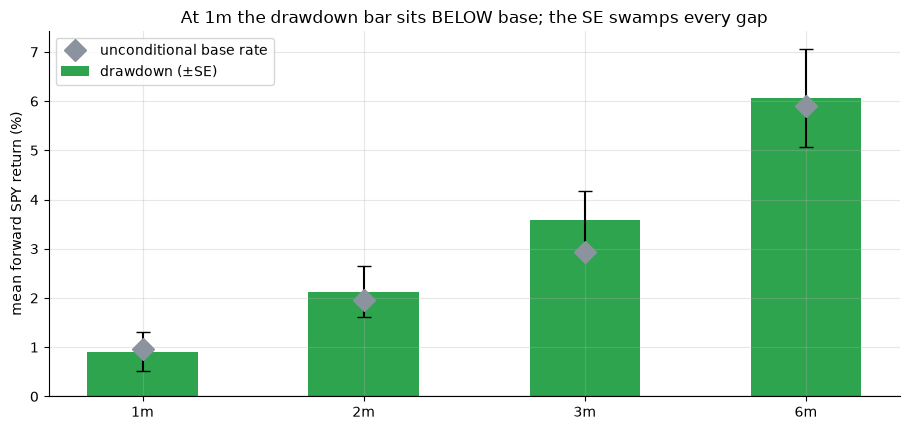

Welch t by horizon: {'1m': -0.11, '2m': 0.27, '3m': 0.85, '6m': 0.13}


In [2]:
hs = [1, 2, 3, 6]
if HAVE_REAL:
    cm, bm, ts, ses = [], [], [], []
    for m in hs:
        s = st.summarize(F, m); cm.append(s['draw_mean']); bm.append(s['base_mean']); ts.append(s['t'])
        d,_b,_a = st.split_returns(F, m); ses.append(d.std(ddof=1)/np.sqrt(len(d)))
else:
    cm = [R['h1'][2]/100, R['h2'][2]/100, R['h3'][2]/100, R['h6'][2]/100]
    bm = [R['h1'][4]/100, R['h2'][4]/100, R['h3'][4]/100, R['h6'][4]/100]
    ts = [R['h1'][7], R['h2'][7], R['h3'][7], R['h6'][7]]; ses = [.011,.017,.021,.03]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x, [c*100 for c in cm], yerr=[s*100 for s in ses], capsize=5, color=GREEN, width=.5, label='drawdown (±SE)')
ax.plot(x, [b*100 for b in bm], 'D', ms=11, c=GREY, label='unconditional base rate')
ax.set_xticks(x); ax.set_xticklabels([f'{m}m' for m in hs]); ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean forward SPY return (%)')
ax.set_title('At 1m the drawdown bar sits BELOW base; the SE swamps every gap'); ax.legend()
plt.tight_layout(); plt.show()
print('Welch t by horizon:', {f'{m}m': round(t,2) for m,t in zip(hs,ts)})

> 💡 In plain words: at 1m the drawdown mean is **+0.91%** vs base **+0.96%** — the *wrong sign* (Welch **t = -0.11**). The only positive gap is at 3m (**t = +0.85**), still far under 2. H₁'s split test is **rejected**: no horizon delivers a significant positive tilt, and the flagship horizon leans the wrong way.

### 4b · The continuous dose-response — HAC (Newey-West) slope ≈ 0

Regress the forward $H$-month return on the injection (per +\$100B drawn down), Newey-West HAC lags $=H$. If the lever is real, more drawdown ⇒ higher return ⇒ a *positive*, significant $\beta$.

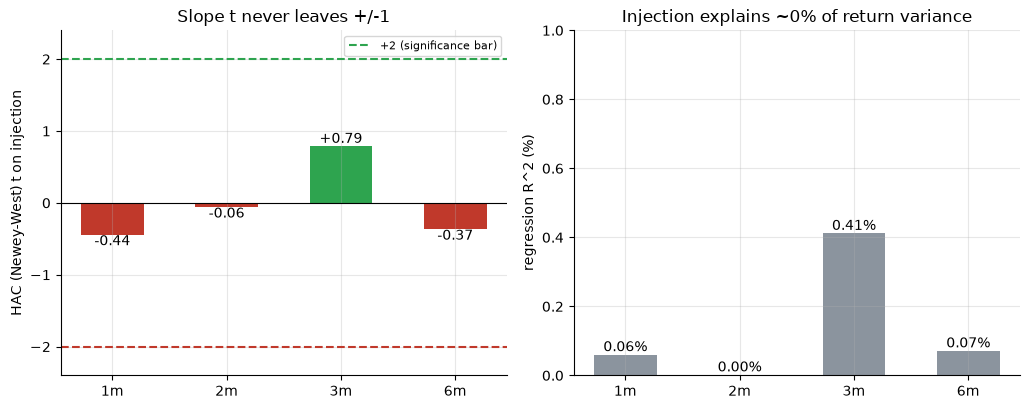

HAC beta (%/+100B), t, R2%: [(-0.11, -0.44, 0.06), (-0.03, -0.06, 0.0), (0.47, 0.79, 0.41), (-0.29, -0.37, 0.07)]


In [3]:
hs = [1, 2, 3, 6]
if HAVE_REAL:
    betas, thac, r2s = [], [], []
    for m in hs:
        rr = st.hac_regression(F, m); betas.append(rr['beta']*100); thac.append(rr['t_hac']); r2s.append(rr['r2']*100)
else:
    betas = [R['reg'][m][0] for m in hs]; thac = [R['reg'][m][1] for m in hs]; r2s = [R['reg'][m][2] for m in hs]
x = np.arange(len(hs))
fig, (a1,a2) = plt.subplots(1, 2, figsize=(10.4, 4.2))
cols = [GREEN if t>0 else RED for t in thac]
a1.bar(x, thac, color=cols, width=.55)
a1.axhline(2, ls='--', c=GREEN, label='+2 (significance bar)'); a1.axhline(-2, ls='--', c=RED)
a1.axhline(0, c='k', lw=.8); a1.set_xticks(x); a1.set_xticklabels([f'{m}m' for m in hs])
a1.set_ylabel('HAC (Newey-West) t on injection'); a1.set_ylim(-2.4, 2.4)
for i,t in enumerate(thac): a1.annotate(f'{t:+.2f}',(i,t),ha='center',va='bottom' if t>=0 else 'top')
a1.set_title('Slope t never leaves +/-1'); a1.legend(fontsize=8)
a2.bar(x, r2s, color=GREY, width=.55); a2.set_xticks(x); a2.set_xticklabels([f'{m}m' for m in hs])
a2.set_ylabel('regression R^2 (%)'); a2.set_ylim(0, 1.0)
for i,v in enumerate(r2s): a2.annotate(f'{v:.2f}%',(i,v),ha='center',va='bottom')
a2.set_title('Injection explains ~0% of return variance')
plt.tight_layout(); plt.show()
print('HAC beta (%/+100B), t, R2%:', [(round(b,2), round(t,2), round(r,2)) for b,t,r in zip(betas,thac,r2s)])

> 💡 In plain words: the slope **flips sign** across horizons (**-0.11%** at 1m, **+0.47%** at 3m, **-0.29%** at 6m per +\$100B) with HAC $t$ inside $\pm1$ and R² ≤ 0.4%. There is **no dose-response**: a bigger drawdown does not buy a bigger return. H₁'s continuous form is **rejected** too.

### 4c · The decisive identification test — lead/lag

$\rho(L) = \mathrm{corr}(x_t, r_{t+L\to t+L+1})$. A real lever dips (rises) on the **right** (positive $L$, injection leads); random co-movement scatters around zero.

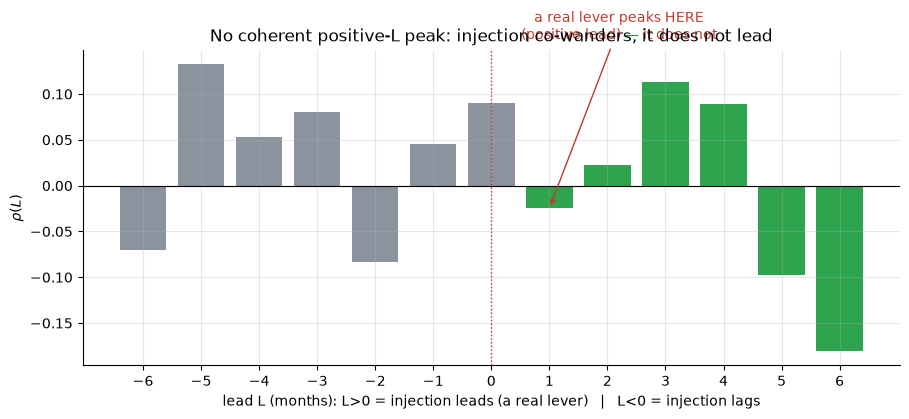

argmax rho at L=-5 (rho=+0.13); rho at +1 = -0.02, at +2 = +0.02


In [4]:
if HAVE_REAL:
    ll = st.lead_lag(F); Ls = list(range(-6,7)); cs = [ll[L] for L in Ls]
else:
    Ls = sorted(R['leadlag']); cs = [R['leadlag'][L] for L in Ls]
cols = [GREEN if L>0 else GREY for L in Ls]
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(Ls, cs, color=cols, width=.8)
ax.axhline(0, c='k', lw=.8); ax.axvline(0, c=RED, lw=1, ls=':')
i1 = Ls.index(1)
ax.annotate('a real lever peaks HERE\n(positive lead) — it does not', xy=(1, cs[i1]),
            xytext=(2.2, 0.16), ha='center', color=RED,
            arrowprops=dict(arrowstyle='->', color=RED))
ax.set_xlabel('lead L (months): L>0 = injection leads (a real lever)   |   L<0 = injection lags')
ax.set_ylabel(r'$\rho(L)$'); ax.set_xticks(Ls)
ax.set_title('No coherent positive-L peak: injection co-wanders, it does not lead')
plt.tight_layout(); plt.show()
imax = int(np.nanargmax(cs))
print(f'argmax rho at L={Ls[imax]} (rho={cs[imax]:+.2f}); rho at +1 = {cs[i1]:+.2f}, at +2 = {cs[Ls.index(2)]:+.2f}')

> 💡 In plain words: $\arg\max_L \rho(L) = -5$ (injection lining up with a *past* market move), while at the positive leads a lever needs — $L=+1,+2$ — $\rho = -0.03, +0.02 \approx 0$. The cross-correlation is structureless noise. **H₂ rejected.** This is the load-bearing result: the TGA injection does not lead equities, independent of the (already-insignificant) conditional mean.

### 4d · Tradability — the hold-on-drawdown overlay loses

Hold SPY when the TGA is drawing down, cash when building (1-month lag, 10 bps/switch). Annualised mean and Sharpe vs buy-and-hold.

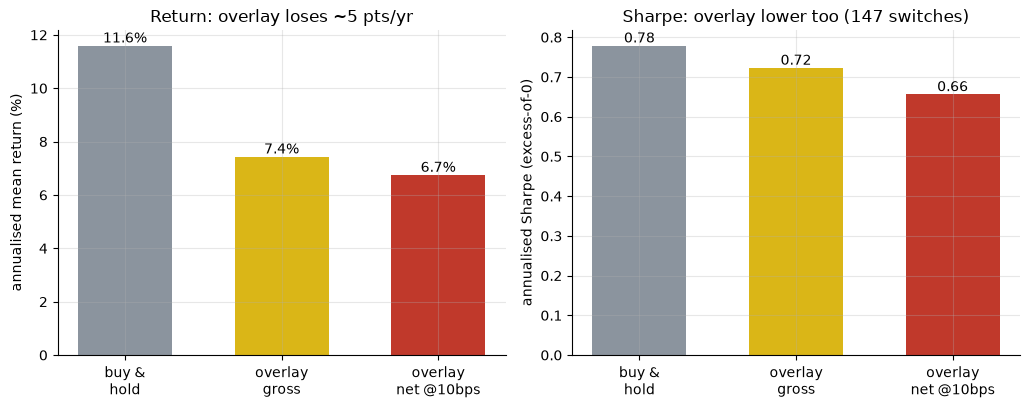

net overlay 6.7%/yr (Sharpe 0.66) vs buy-hold 11.6%/yr (Sharpe 0.78)


In [5]:
if HAVE_REAL:
    o = st.timing_overlay(F, cost_bps=10.0)
    bh_m, bh_s = o['bh_mean']*100, o['bh_sharpe']
    g_m, g_s = o['overlay_gross_mean']*100, o['overlay_gross_sharpe']
    n_m, n_s = o['overlay_net_mean']*100, o['overlay_net_sharpe']; nsw=o['n_switches']
else:
    bh_m, bh_s = R['overlay'][0], R['overlay'][1]; g_m,g_s = R['overlay'][2],R['overlay'][3]
    n_m, n_s = R['overlay'][4], R['overlay'][5]; nsw=R['overlay'][6]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.4, 4.2))
labels = ['buy &\nhold', 'overlay\ngross', 'overlay\nnet @10bps']
a1.bar(labels, [bh_m, g_m, n_m], color=[GREY, AMBER, RED], width=.6)
for i,v in enumerate([bh_m,g_m,n_m]): a1.annotate(f'{v:.1f}%',(i,v),ha='center',va='bottom')
a1.set_ylabel('annualised mean return (%)'); a1.set_title('Return: overlay loses ~5 pts/yr')
a2.bar(labels, [bh_s, g_s, n_s], color=[GREY, AMBER, RED], width=.6)
for i,v in enumerate([bh_s,g_s,n_s]): a2.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom')
a2.set_ylabel('annualised Sharpe (excess-of-0)'); a2.set_title(f'Sharpe: overlay lower too ({nsw} switches)')
plt.tight_layout(); plt.show()
print(f'net overlay {n_m:.1f}%/yr (Sharpe {n_s:.2f}) vs buy-hold {bh_m:.1f}%/yr (Sharpe {bh_s:.2f})')

> 💡 In plain words: the overlay returns **+6.7%/yr** net vs **+11.6%** for buy-and-hold, with a *lower* Sharpe (0.66 vs 0.78) and 147 switches. Because the TGA *builds* through large stretches of bull markets (post-2016, post-2023), sitting out on 'building' forfeits upside. **H₃ rejected** — costs aren't even the issue; the *timing* loses. `MIRAGE`.

### 4e · Robustness — window and the COVID dependence

Vary the change window $k$ and drop the COVID balloon-and-drawdown (2020–mid-2021). The 1-month *t* never clears 2, and dropping COVID leaves it *negative*.

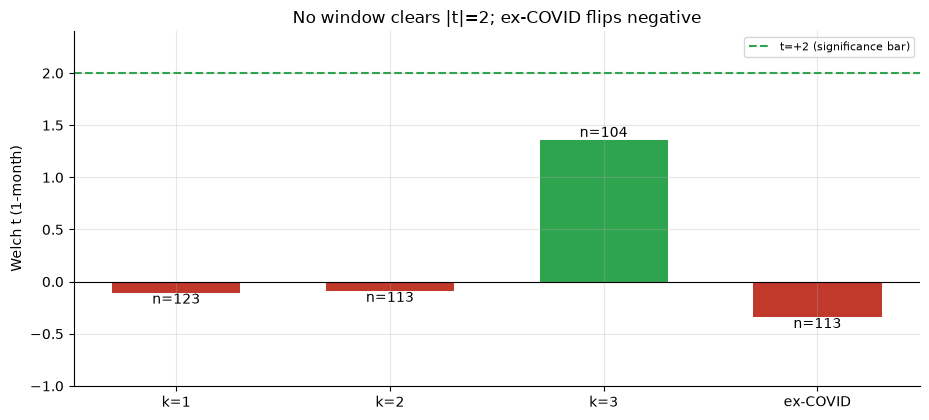

robustness (label, n, draw1%, Welch_t, HAC_t): [('k=1', 123, 0.91, -0.11, -0.44), ('k=2', 113, 0.92, -0.09, -0.02), ('k=3', 104, 1.58, 1.36, 0.75), ('ex-COVID', 113, 0.87, -0.34, 0.24)]


In [6]:
if HAVE_REAL:
    rob = []
    for k in (1,2,3):
        s = st.summarize(F, 1, k=k); rob.append((f'k={k}', s['n_draw'], s['draw_mean']*100, s['t'], s['t_hac']))
    F2 = F[(F.index < '2020-01-01') | (F.index >= '2021-07-01')]
    s = st.summarize(F2, 1); rob.append(('ex-COVID', s['n_draw'], s['draw_mean']*100, s['t'], s['t_hac']))
else:
    rob = [(l,n,d,wt,ht) for (l,n,d,_b,wt,ht) in R['robust']]
labels = [r[0] for r in rob]; tt = [r[3] for r in rob]; nn = [r[1] for r in rob]
cols = [GREEN if t>0 else RED for t in tt]
fig, ax = plt.subplots(figsize=(9.4, 4.3))
ax.bar(labels, tt, color=cols, width=.6)
ax.axhline(2, ls='--', c=GREEN, label='t=+2 (significance bar)')
ax.axhline(0, c='k', lw=.8)
for i,(t,k) in enumerate(zip(tt,nn)): ax.annotate(f'n={k}',(i,t),ha='center',va='bottom' if t>=0 else 'top')
ax.set_ylabel('Welch t (1-month)'); ax.set_ylim(-1, 2.4)
ax.set_title('No window clears |t|=2; ex-COVID flips negative'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print('robustness (label, n, draw1%, Welch_t, HAC_t):', [(r[0], r[1], round(r[2],2), round(r[3],2), round(r[4],2)) for r in rob])

> 💡 In plain words: the best reading is the slow **k=3** window (**Welch t=1.36**) — still under 2, and a 3-month-old drawdown trend is a weaker version of the 'immediate injection' the thesis sells. Drop COVID and the 1-month *t* is **-0.34** — the *wrong sign*. No specification rescues a signal.

### 4f · Faithful-engine control — we know the truth here

A deterministic monthly series with a *planted* link (a drawdown at $t$ lifts the **capturable** $[t{+}1,t{+}2]$ forward return by `edge`). With `edge=0` the test must stay flat; with a large `edge` both the Welch and HAC tests must light up — proving the engine is unbiased and the real-tape null isn't a measurement failure.

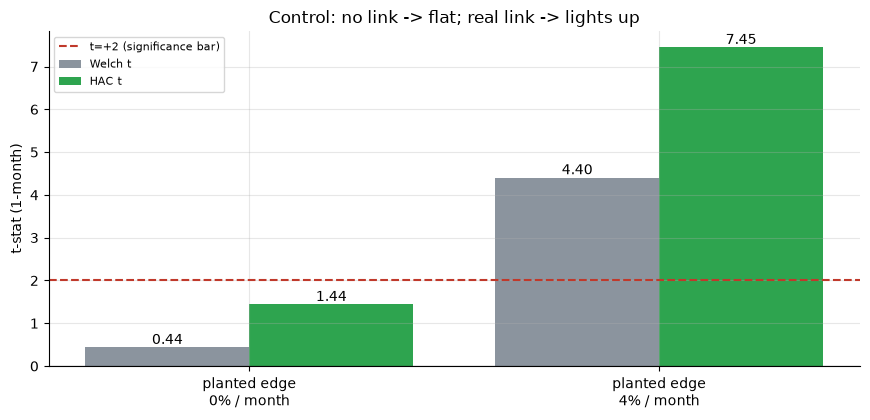

planted +0%/mo: n_draw=128 draw=0.74% base=0.54% Welch_t=0.44 HAC_t=1.44 p=0.294
planted +4%/mo: n_draw=128 draw=4.85% base=2.64% Welch_t=4.40 HAC_t=7.45 p=0.000


In [7]:
res = []
for edge in (0.0, 0.04):
    syn = data.synthetic_tga(n_months=252, edge=edge, seed=752)
    s = st.summarize(syn, 1, k=1)
    res.append((edge, s['n_draw'], s['draw_mean']*100, s['base_mean']*100, s['t'], s['t_hac'], s['p_placebo']))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
labels = [f'planted edge\n{e*100:.0f}% / month' for e,*_ in res]
wt = [r[4] for r in res]; ht = [r[5] for r in res]
xb = np.arange(len(res))
ax.bar(xb-.2, wt, .4, color=GREY, label='Welch t')
ax.bar(xb+.2, ht, .4, color=GREEN, label='HAC t')
ax.axhline(2, ls='--', c=RED, label='t=+2 (significance bar)'); ax.axhline(0, c='k', lw=.8)
ax.set_xticks(xb); ax.set_xticklabels(labels)
for i,(a,b) in enumerate(zip(wt,ht)):
    ax.annotate(f'{a:.2f}',(i-.2,a),ha='center',va='bottom')
    ax.annotate(f'{b:.2f}',(i+.2,b),ha='center',va='bottom')
ax.set_ylabel('t-stat (1-month)'); ax.set_title('Control: no link -> flat; real link -> lights up'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
for e,k,c,b,t,ht_,p in res: print(f'planted {e*100:+.0f}%/mo: n_draw={k} draw={c:.2f}% base={b:.2f}% Welch_t={t:.2f} HAC_t={ht_:.2f} p={p:.3f}')

> 💡 In plain words: with **no** planted link the headline Welch test sits at **t = +0.44** (placebo p=0.29 — no false positive); a **+4%/month** planted link drives **Welch t = +4.40** and **HAC t = +7.45**. The machinery is honest and *does* bank a real drawdown→returns link — so the real-tape null (Welch/HAC $t\approx0$) is a *genuine* absence of edge, not a broken test.

## 5 · The verdict

- **Signal `NONE`** — 1m drawdown excess **-0.05pp** (*wrong sign*) at Welch **t = -0.11**; best horizon (3m) only **t = +0.85**; the HAC slope flips sign across horizons with $|t|<1$ and R² ≤ 0.4%. No conditional tilt and no dose-response — indistinguishable from noise.
- **Tradability `MIRAGE`** — the hold-on-drawdown overlay returns **+6.7%/yr** (Sharpe 0.66) vs buy-hold **+11.6%/yr** (Sharpe 0.78). Acting on the signal *subtracts* return — nothing to allocate to.
- **Hidden liquidity lever? `NOT SUPPORTED`** — the lead/lag scan is structureless ($\rho\approx0$ at $L=+1,+2$; extremes at $L=-5,+6$). The injection co-wanders with a shared macro backdrop rather than leading the market. The mechanism the story rests on doesn't show up in the tape.

## 6 · Could you trade it? — why even a real tilt wouldn't deploy

Grant the lore a whisper of an edge. The operational reality still defeats it. The TGA draws down in **~48% of months** (every down-wiggle of a noisy monthly series), so the overlay churns (147 switches / 21y) and is out of the market in roughly half of all months — including large stretches of bull runs when the Treasury was *rebuilding* cash. That structural mistiming is why the overlay's Sharpe is **below** passive even at zero cost. And the identification is fatal: the deepest drawdowns are **debt-ceiling** episodes — the Treasury spending its last cash because it *can't issue debt* — a stressed regime, not a stimulative one. The 'net liquidity' composite (subtracting the reverse-repo facility too) is the natural next test, but a monthly TGA null this flat, with no lead structure, is not a promising base to build on.

## 7 · Going further

- **The sibling.** [Study 385 — Jobless-Claims-Momentum](../385-jobless-claims-momentum/): a famous 'leading' macro series, same hardcoded-snapshot + SPY method — real signal, un-tradable timing.
- **The full composite.** Build **net liquidity** = Fed balance sheet − TGA − RRP and rerun the identification test; the reverse-repo term is exactly what muted the 2022–23 TGA rebuild's predicted drain, so it's the fair steelman.
- **Weekly resolution + real-time vintages.** Replace the monthly proxy with the true weekly `WTREGEN` (and DTS same-day operating balance) and test 1–4 week horizons with a proper VAR / Granger test; the coincident, no-lead structure is unlikely to survive into a lead at a finer clock, but it is the honest next experiment.

*The reproducible core is offline and deterministic; the TGA input is an explicit labelled monthly proxy. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*